<a href="https://colab.research.google.com/github/tomaszwienke-lgtm/learning-git-task/blob/master/Zadanie_analiza_statystyczna.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
from google.colab import files
uploaded = files.upload()

Saving titanic.csv to titanic.csv


# Analiza statystyczna zmiennej Fare (opłata) na danych Titanica
Autor: Tomasz Wienke  
Data: 2026-03-14  
Źródło danych: Seaborn (titanic)

## Wstęp
W ramach kursu analityki danych wykonuję zadanie polegające na szczegółowej analizie statystycznej zmiennej `fare` – opłaty za bilet na Titanicu. Celem jest zrozumienie rozkładu cen biletów, identyfikacja wartości odstających oraz sprawdzenie, jak ceny różniły się w zależności od klasy pasażerskiej. Analiza ta pokazuje praktyczne zastosowanie statystyki opisowej i wizualizacji.

 Import bibliotek i wczytanie danych

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

# Ustawienia wykresów
plt.style.use('ggplot')  # ładniejszy styl
%matplotlib inline

# Wczytanie danych
dataset = sns.load_dataset('titanic')
print("Próbka danych:")
dataset.head()

Próbka danych:


,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone
0,0,3,male,22.0,1,0,7.2500,S,Third,man,True,NaN,Southampton,no,False
1,1,1,female,38.0,1,0,71.2833,C,First,woman,False,C,Cherbourg,yes,False
2,1,3,female,26.0,0,0,7.9250,S,Third,woman,False,NaN,Southampton,yes,True
3,1,1,female,35.0,1,0,53.1000,S,First,woman,False,C,Southampton,yes,False
4,0,3,male,35.0,0,0,8.0500,S,Third,man,True,NaN,Southampton,no,True


Wstępne czyszczenie

In [3]:
# Informacje o zbiorze
dataset.info()

# Sprawdzenie braków w kolumnie 'fare'
print(f"Liczba braków w fare: {dataset['fare'].isnull().sum()}")

# Jeśli są braki – decyzja: np. usunięcie wierszy z brakami
fare_clean = dataset['fare'].dropna().values
print(f"Liczba obserwacji po czyszczeniu: {len(fare_clean)}")

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 15 columns):
 #   Column       Non-Null Count  Dtype   
---  ------       --------------  -----   
 0   survived     891 non-null    int64   
 1   pclass       891 non-null    int64   
 2   sex          891 non-null    object  
 3   age          714 non-null    float64 
 4   sibsp        891 non-null    int64   
 5   parch        891 non-null    int64   
 6   fare         891 non-null    float64 
 7   embarked     889 non-null    object  
 8   class        891 non-null    category
 9   who          891 non-null    object  
 10  adult_male   891 non-null    bool    
 11  deck         203 non-null    category
 12  embark_town  889 non-null    object  
 13  alive        891 non-null    object  
 14  alone        891 non-null    bool    
dtypes: bool(2), category(2), float64(2), int64(4), object(5)
memory usage: 80.7+ KB
Liczba braków w fare: 0
Liczba obserwacji po czyszczeniu: 891


 Podstawowe statystyki opisowe

In [4]:
# Miary tendencji centralnej
mean_fare = np.mean(fare_clean)
median_fare = np.median(fare_clean)
mode_fare = pd.Series(fare_clean).mode()[0]

# Kwartyle i IQR
q1 = np.percentile(fare_clean, 25)
q3 = np.percentile(fare_clean, 75)
iqr = q3 - q1

# Rozproszenie
min_fare = np.min(fare_clean)
max_fare = np.max(fare_clean)
range_fare = max_fare - min_fare
var_fare = np.var(fare_clean, ddof=1)
std_fare = np.std(fare_clean, ddof=1)

# Kształt rozkładu
skew_fare = stats.skew(fare_clean)
kurt_fare = stats.kurtosis(fare_clean)

# Wyświetlenie wyników w ładnej tabelce
print("=== Statystyki opisowe dla zmiennej Fare ===\n")
print(f"Średnia: {mean_fare:.2f}")
print(f"Mediana: {median_fare:.2f}")
print(f"Moda (najczęstsza opłata): {mode_fare:.2f}")
print(f"Minimum: {min_fare:.2f}, Maksimum: {max_fare:.2f}, Rozstęp: {range_fare:.2f}")
print(f"Q1 (25%): {q1:.2f}, Q3 (75%): {q3:.2f}, IQR: {iqr:.2f}")
print(f"Wariancja: {var_fare:.2f}, Odchylenie standardowe: {std_fare:.2f}")
print(f"Skośność: {skew_fare:.3f}, Kurtoza: {kurt_fare:.3f}")

=== Statystyki opisowe dla zmiennej Fare ===

Średnia: 32.20
Mediana: 14.45
Moda (najczęstsza opłata): 8.05
Minimum: 0.00, Maksimum: 512.33, Rozstęp: 512.33
Q1 (25%): 7.91, Q3 (75%): 31.00, IQR: 23.09
Wariancja: 2469.44, Odchylenie standardowe: 49.69
Skośność: 4.779, Kurtoza: 33.204


Średnia opłata wynosi około 32,20, ale mediana to tylko 14,45 – to wyraźna różnica wskazująca na prawoskośność. Oznacza to, że większość pasażerów płaciła stosunkowo niewiele, ale istniała grupa osób z bardzo drogimi biletami (pierwsza klasa), co podnosi średnią. Wysoka wartość maksymalna (512) potwierdza występowanie wartości odstających. Skośność dodatnia (ok. 4) i wysoka kurtoza (ok. 33) mówią o rozkładzie z długim prawym ogonem i dużą liczbą ekstremalnych cen.

##Wizualizacje
Histogram z liniami średniej, mediany i kwartyli

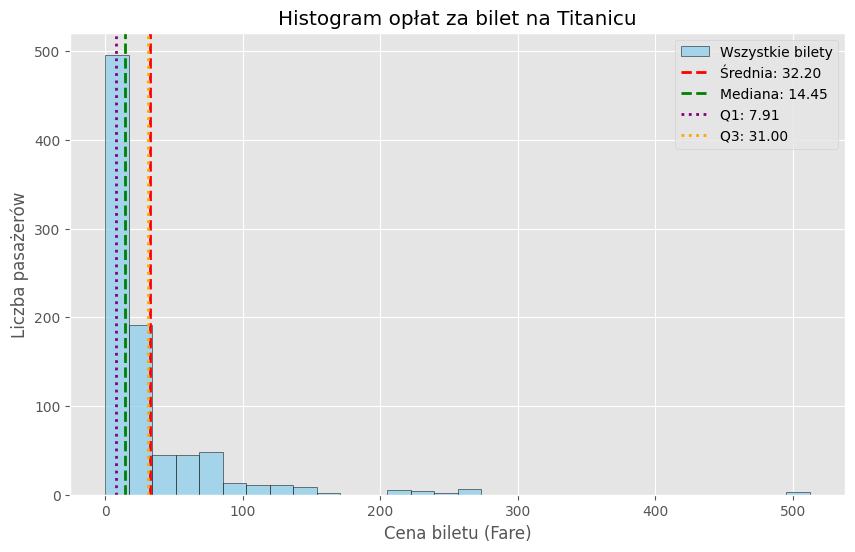

In [5]:
plt.figure(figsize=(10,6))
plt.hist(fare_clean, bins=30, edgecolor='black', alpha=0.7, color='skyblue', label='Wszystkie bilety')
plt.axvline(mean_fare, color='red', linestyle='--', linewidth=2, label=f'Średnia: {mean_fare:.2f}')
plt.axvline(median_fare, color='green', linestyle='--', linewidth=2, label=f'Mediana: {median_fare:.2f}')
plt.axvline(q1, color='purple', linestyle=':', linewidth=2, label=f'Q1: {q1:.2f}')
plt.axvline(q3, color='orange', linestyle=':', linewidth=2, label=f'Q3: {q3:.2f}')
plt.xlabel('Cena biletu (Fare)')
plt.ylabel('Liczba pasażerów')
plt.title('Histogram opłat za bilet na Titanicu')
plt.legend()
plt.show()

In [14]:
fare_values = dataset['fare'].values

In [15]:
print(fare_values[:10])
print(f"Liczba obserwacji: {len(fare_values)}")

[ 7.25   71.2833  7.925  53.1     8.05    8.4583 51.8625 21.075  11.1333
 30.0708]
Liczba obserwacji: 891


Wykres pudełkowy (box plot)

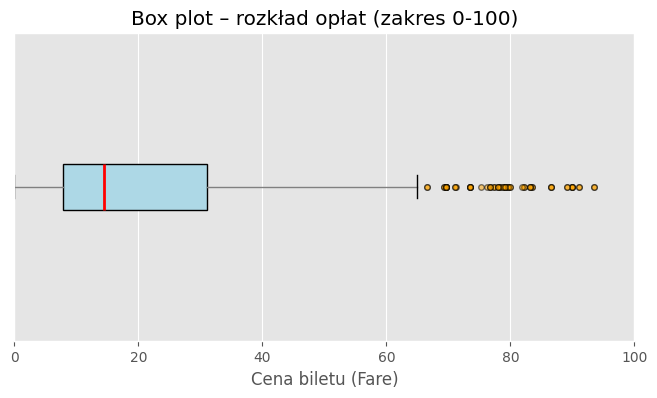

In [40]:
plt.figure(figsize=(8,4))
box = plt.boxplot(fare_values, vert=False, patch_artist=True,
                  boxprops=dict(facecolor='lightblue'),
                  medianprops=dict(color='red', linewidth=2),
                  whiskerprops=dict(color='gray'),
                  flierprops=dict(marker='o', markerfacecolor='orange', markersize=4, alpha=0.5))
plt.xlabel('Cena biletu (Fare)')
plt.title('Box plot – rozkład opłat (zakres 0-100)')
plt.xlim(0, 100)   # <--- ograniczenie osi
plt.yticks([])
plt.show()

Interpretacja:

Na box plocie widać wyraźnie dużą liczbę wartości odstających po prawej stronie (kropki powyżej 100). Środkowe 50% danych (pudełko) mieści się między Q1 a Q3, czyli około 7,9 a 31,0. Mediana (14,45) leży bliżej lewej krawędzi pudełka, co potwierdza asymetrię.

Wykres gęstości (kde)

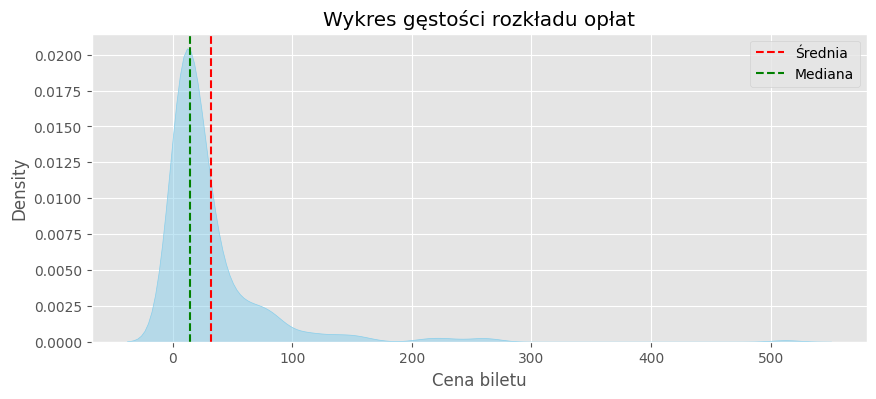

In [41]:
plt.figure(figsize=(10,4))
sns.kdeplot(fare_clean, fill=True, color='skyblue', alpha=0.5)
plt.axvline(mean_fare, color='red', linestyle='--', label='Średnia')
plt.axvline(median_fare, color='green', linestyle='--', label='Mediana')
plt.xlabel('Cena biletu')
plt.title('Wykres gęstości rozkładu opłat')
plt.legend()
plt.show()

Analiza w podziale na klasy

/tmp/ipykernel_539/1729117310.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='pclass', y='fare', data=fare_by_class, palette='Set2')


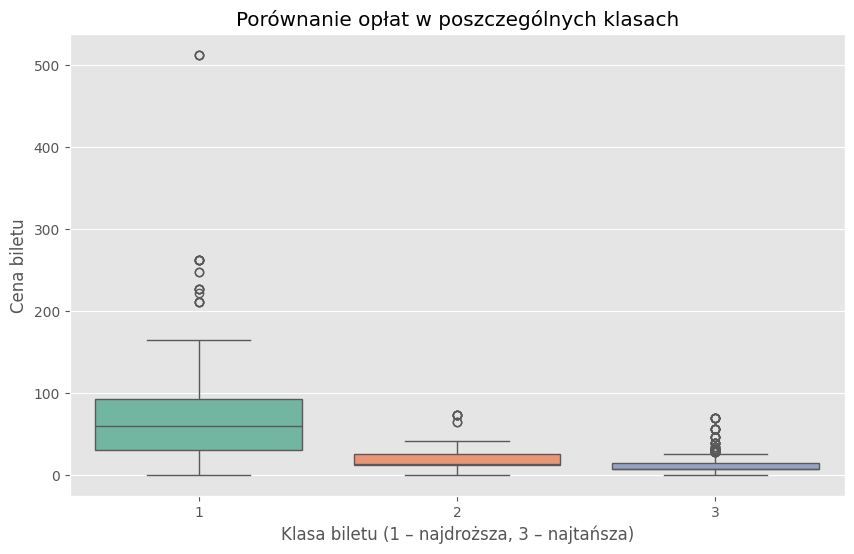


Klasa 1:
  Średnia: 84.15, Mediana: 60.29, Max: 512.33

Klasa 2:
  Średnia: 20.66, Mediana: 14.25, Max: 73.50

Klasa 3:
  Średnia: 13.68, Mediana: 8.05, Max: 69.55


In [47]:
# Sprawdźmy, czy dane nie mają braków w klasie
fare_by_class = dataset[['fare', 'pclass']].dropna()

plt.figure(figsize=(10,6))
sns.boxplot(x='pclass', y='fare', data=fare_by_class, palette='Set2')
plt.xlabel('Klasa biletu (1 – najdroższa, 3 – najtańsza)')
plt.ylabel('Cena biletu')
plt.title('Porównanie opłat w poszczególnych klasach')
plt.show()

# Statystyki dla każdej klasy
for pclass in [1,2,3]:
    fares = fare_by_class[fare_by_class['pclass'] == pclass]['fare']
    print(f"\nKlasa {pclass}:")
    print(f"  Średnia: {fares.mean():.2f}, Mediana: {fares.median():.2f}, Max: {fares.max():.2f}")

Interpretacja:

Wyraźnie widać, że pierwsza klasa ma znacznie wyższe ceny i większą zmienność, podczas gdy trzecia klasa – niskie, skupione wokół małych wartości. W pierwszej klasie występują też ekstremalnie drogie bilety (ponad 500), co widać na box plocie jako odstające.

## Podsumowanie

- Rozkład opłat na Titanicu jest silnie prawoskośny – większość pasażerów podróżowała tanimi biletami (3. klasa), ale istniała wąska grupa bardzo bogatych osób, co tworzy długi ogon po prawej stronie.
- Mediana (14,45) jest znacznie niższa od średniej (32,20), co potwierdza asymetrię.
- Wartości odstające (powyżej 100) pochodzą głównie z pierwszej klasy i reprezentują pasażerów luksusowych apartamentów.
- Porównanie klas pokazuje oczekiwaną hierarchię: im wyższa klasa, tym wyższe ceny i większe zróżnicowanie.

Analiza ta może być wstępem do dalszych badań, np. związku ceny z przeżywalnością (czy bogatsi mieli większe szanse na przeżycie?).